In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Clustering
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

# Classification Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# XGBoost
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    accuracy_score,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv')

In [3]:
df = pd.DataFrame(data)
df 

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [4]:
df.shape

(167, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

# EDA

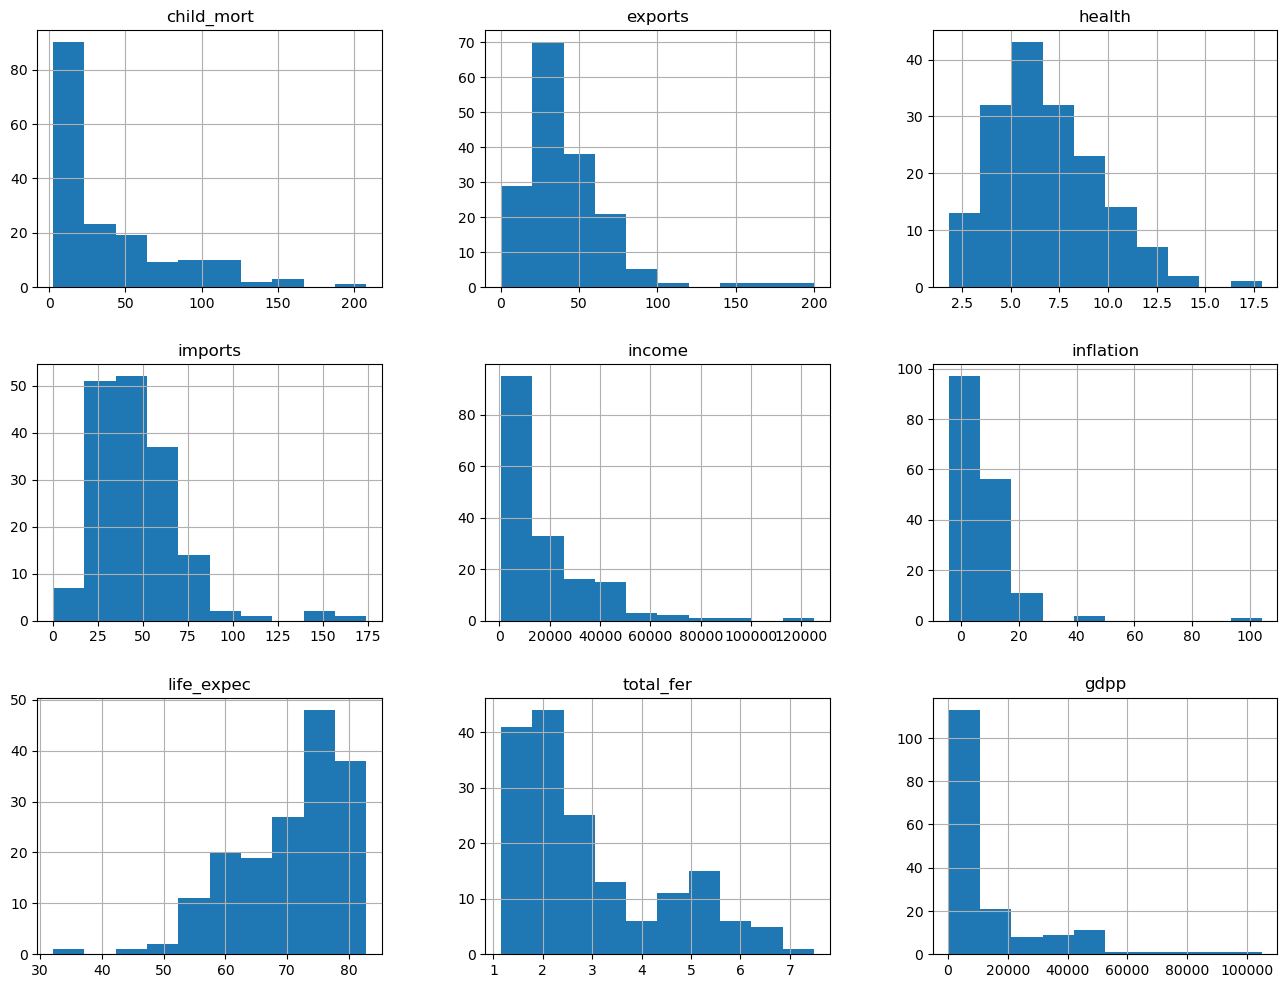

In [8]:
#Distribution Plots
df.hist(figsize=(16,12))
plt.show()

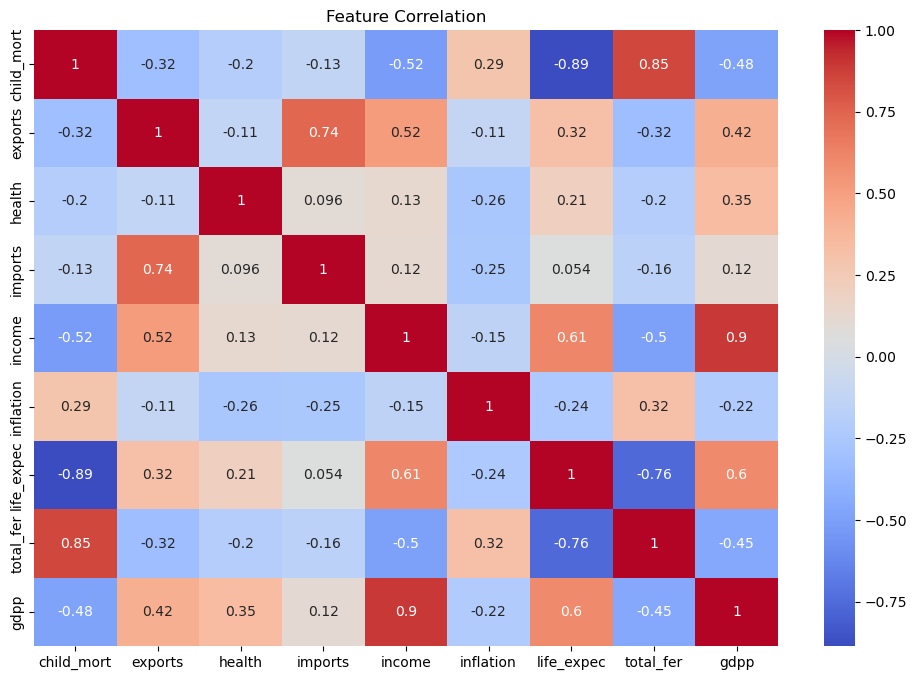

In [9]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

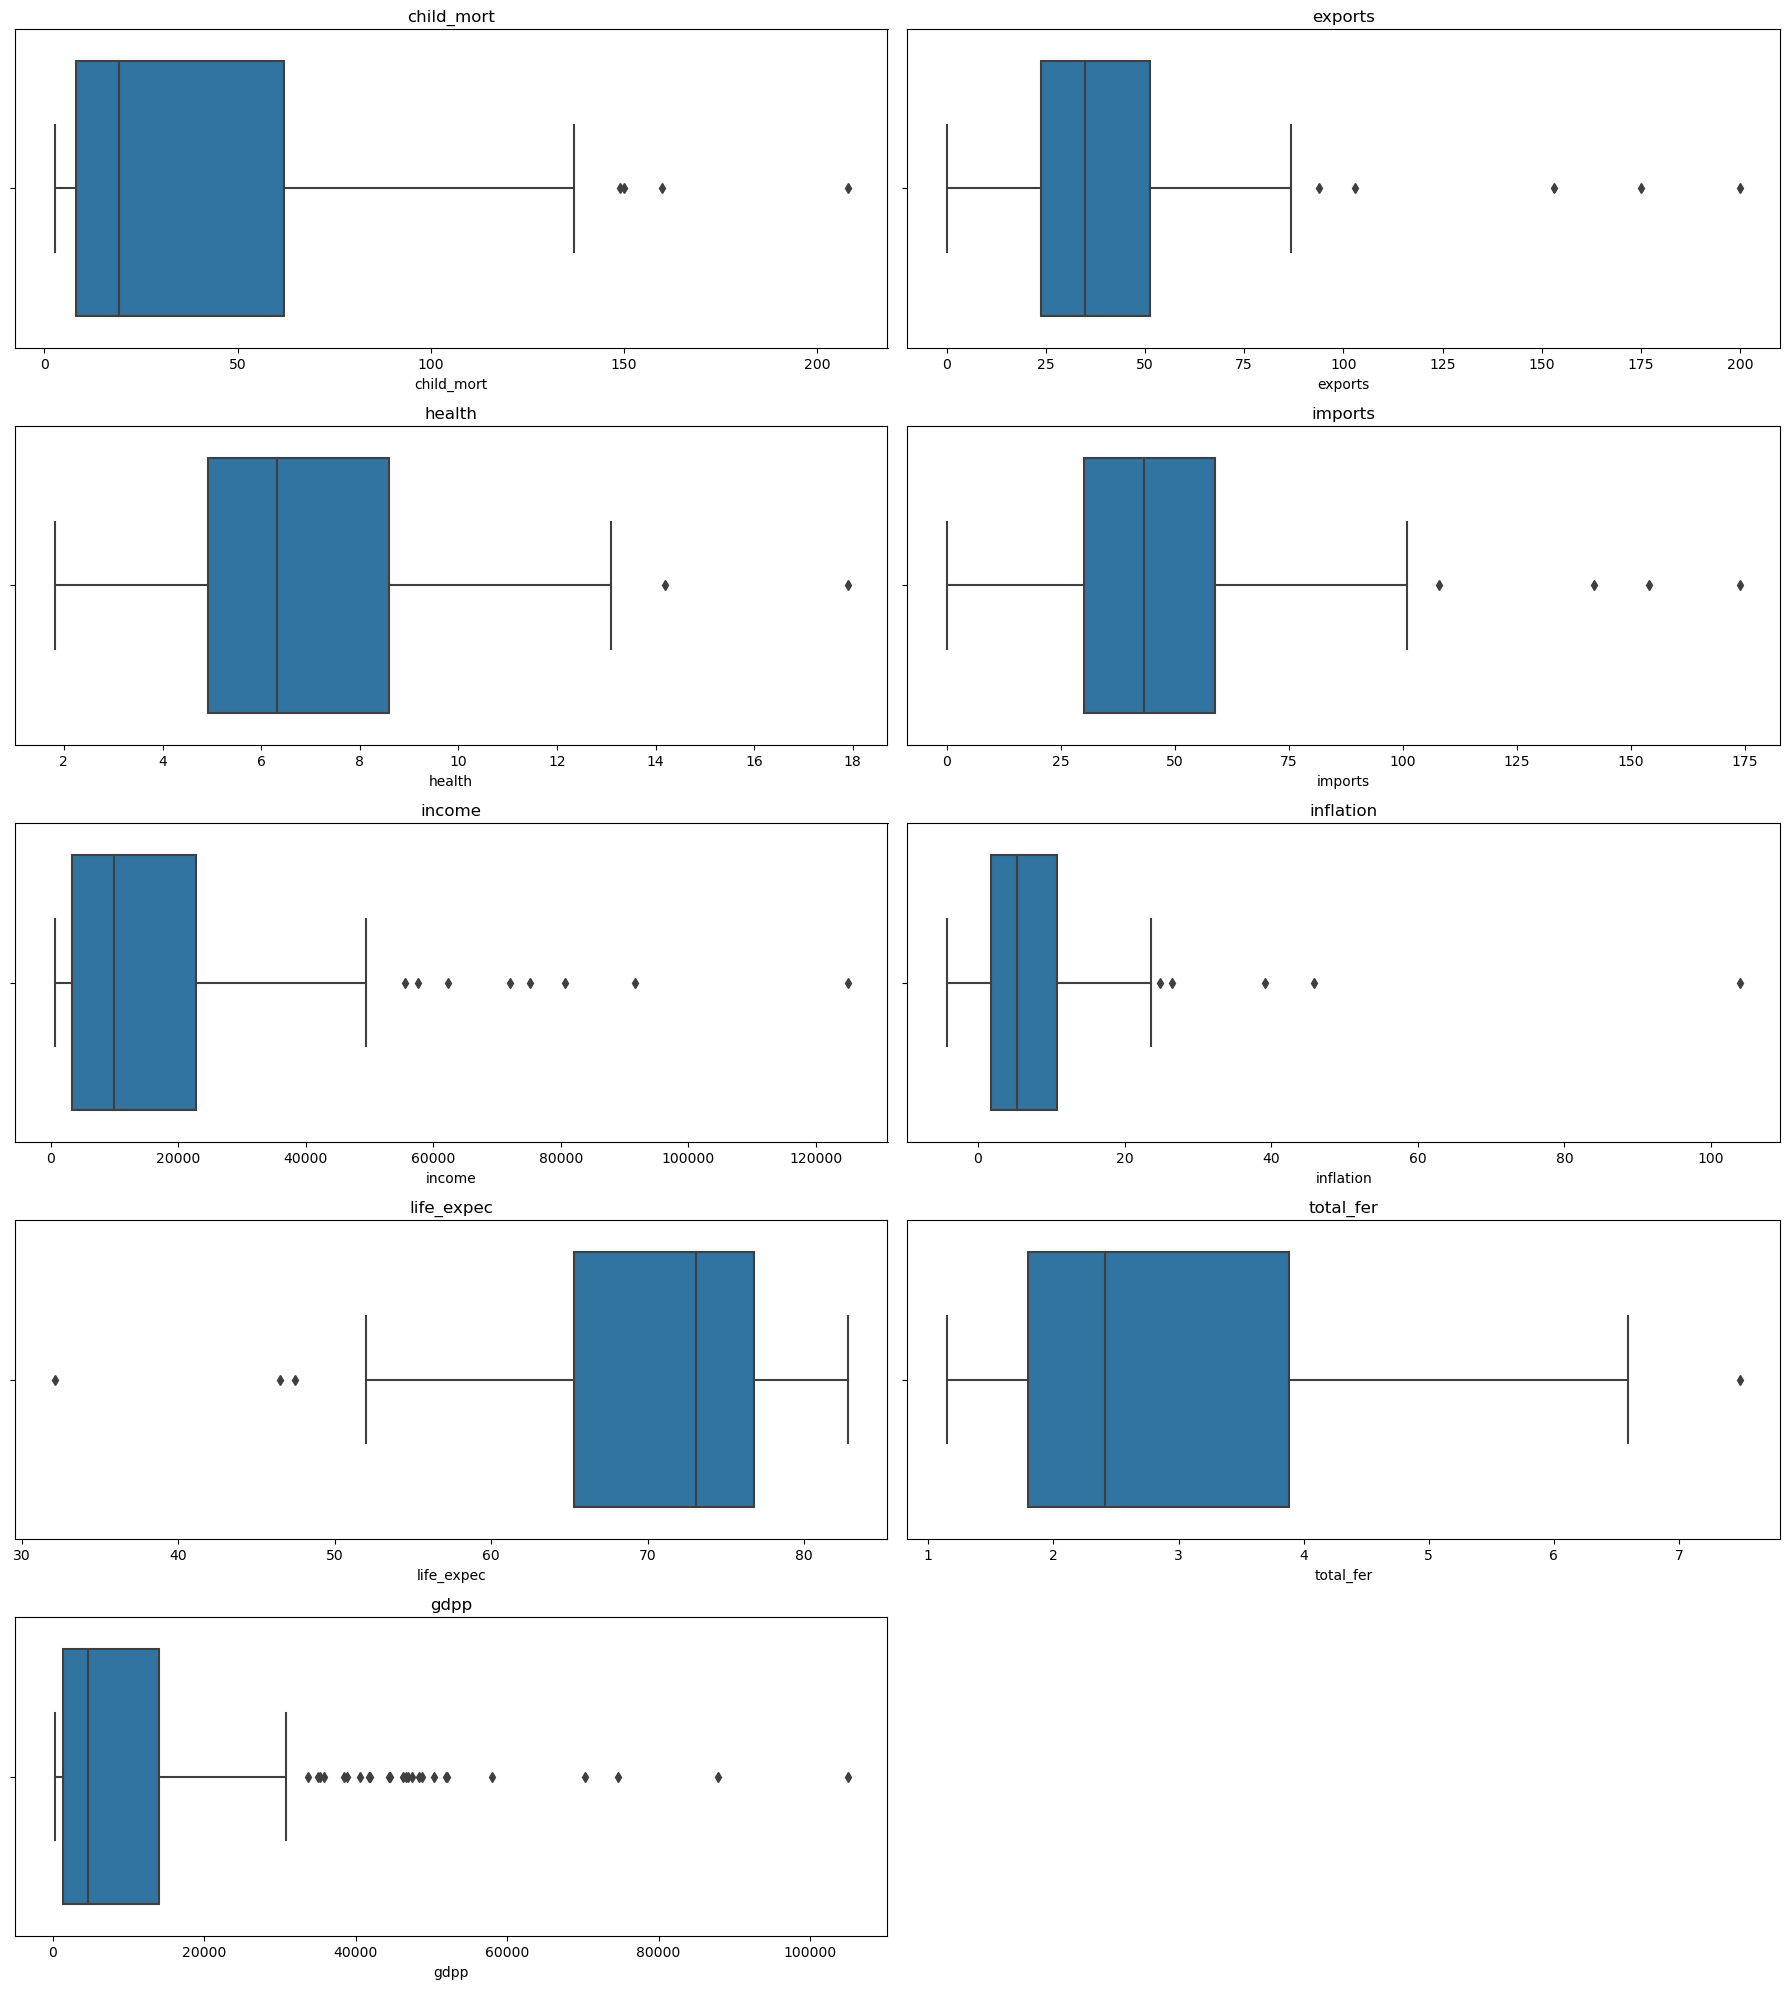

In [10]:
#Boxplots for Outlier Detection
num_cols = df.columns[1:]
plt.figure(figsize=(18,20))
for i,col in enumerate(num_cols):
    plt.subplot(5,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
#Remove country column
X = df.drop('country', axis=1)

#Save feature names
feature_names = X.columns

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA

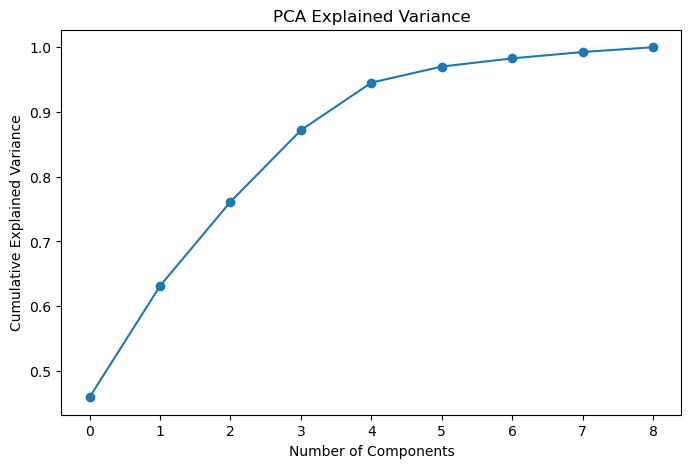

In [13]:
pca = PCA()
pca.fit(X_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca,columns=['PC1', 'PC2'])
X_pca.head()

,PC1,PC2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


# CLUSTERING COMPARISON

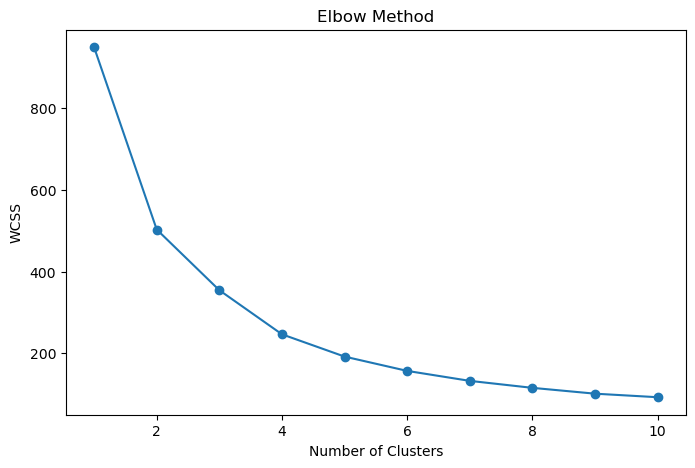

In [15]:
#k means elbow method
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [16]:
#KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

In [17]:
#DBSCAN
dbscan = DBSCAN(eps=0.8,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

In [18]:
#Hierarchical 
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_pca)

In [19]:
#Cluster Evaluation
cluster_results = pd.DataFrame({
    "Model": ["KMeans", "Agglomerative"],
    "Silhouette": [
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, agg_labels)

    ],
    "Davies_Bouldin": [
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, agg_labels)
    ],
    "Calinski_Harabasz": [
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, agg_labels)
    ]
})
cluster_results

,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,KMeans,0.442497,0.682420,137.475711
1,Agglomerative,0.430843,0.696306,133.627445


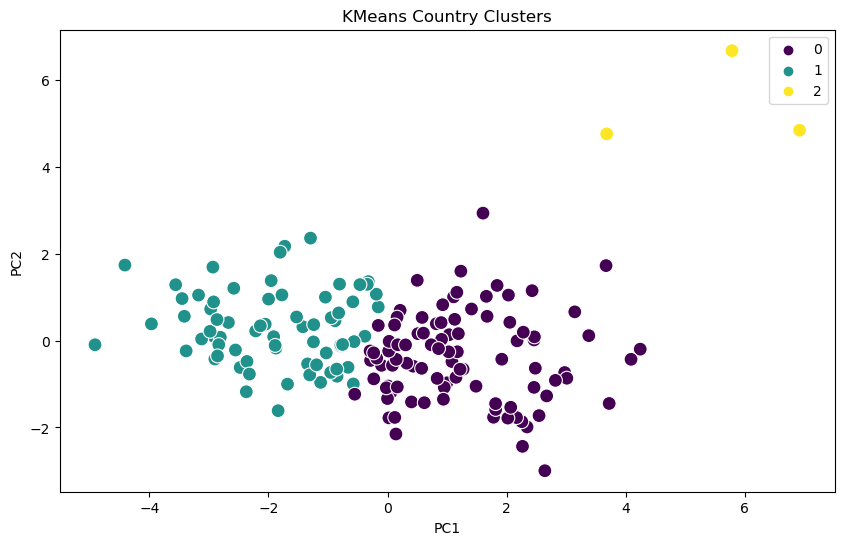

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca['PC1'],
    y=X_pca['PC2'],
    hue=kmeans_labels,
    palette='viridis',
    s=100
)
plt.title("KMeans Country Clusters")
plt.show()

In [21]:
df['Cluster'] = kmeans_labels

In [22]:
#cluster analysis
cluster_analysis = df.groupby('Cluster').mean(numeric_only=True)
cluster_analysis

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,11.974194,44.772043,7.426989,45.501075,25390.000000,5.423946,76.524731,1.943871,19881.182796
1,74.156338,30.611254,6.015915,44.071351,4363.281690,11.094859,62.277465,4.329437,2019.211268
2,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


From the above table, we get to know this:
| Cluster | Meaning |
|----------|----------|
| **Cluster 0** | Developing Countries |
| **Cluster 1** | Underdeveloped / Help Needed |
| **Cluster 2** | Developed Countries |

In [23]:
df['Cluster'].value_counts()

0    93
1    71
2     3
Name: Cluster, dtype: int64

In [24]:
#Find Countries Needing Help
help_needed = df[df['Cluster'] == 1]

In [25]:
# Sort most critical countries
help_needed = help_needed.sort_values(by=['child_mort', 'gdpp'],ascending=[False, True])
help_needed[['country','child_mort','income','life_expec','gdpp']].head(20)

,country,child_mort,income,life_expec,gdpp
66,Haiti,208.0,1500,32.1,662
132,Sierra Leone,160.0,1220,55.0,399
32,Chad,150.0,1930,56.5,897
31,Central African Republic,149.0,888,47.5,446
97,Mali,137.0,1870,59.5,708
113,Nigeria,130.0,5150,60.5,2330
112,Niger,123.0,814,58.8,348
3,Angola,119.0,5900,60.1,3530
37,"Congo, Dem. Rep.",116.0,609,57.5,334
25,Burkina Faso,116.0,1430,57.9,575


# CLASSIFICATION

In [26]:
#Train Test Split
X = X_scaled
y = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
#Models
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

In [28]:
#Train and Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    results.append([name, accuracy])
    print("="*50)
    print(name)
    print("Accuracy:", accuracy)
    print(classification_report(y_test,y_pred))

KNN
Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      1.00      1.00        13
           2       0.00      0.00      0.00         2

    accuracy                           0.94        34
   macro avg       0.63      0.67      0.65        34
weighted avg       0.89      0.94      0.91        34

Naive Bayes
Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        19
           1       0.76      1.00      0.87        13
           2       0.00      0.00      0.00         2

    accuracy                           0.82        34
   macro avg       0.55      0.60      0.57        34
weighted avg       0.79      0.82      0.80        34

SVM
Accuracy: 0.9117647058823529
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.9

# MODEL COMPARISON

In [29]:
results_df = pd.DataFrame(results,columns=['Model','Accuracy'])
results_df = results_df.sort_values(by='Accuracy',ascending=False)
results_df

,Model,Accuracy
0,KNN,0.941176
3,Decision Tree,0.941176
2,SVM,0.911765
4,Random Forest,0.882353
5,AdaBoost,0.882353
6,Gradient Boosting,0.882353
7,XGBoost,0.882353
1,Naive Bayes,0.823529


# VISUALIZE PERFORMANCE

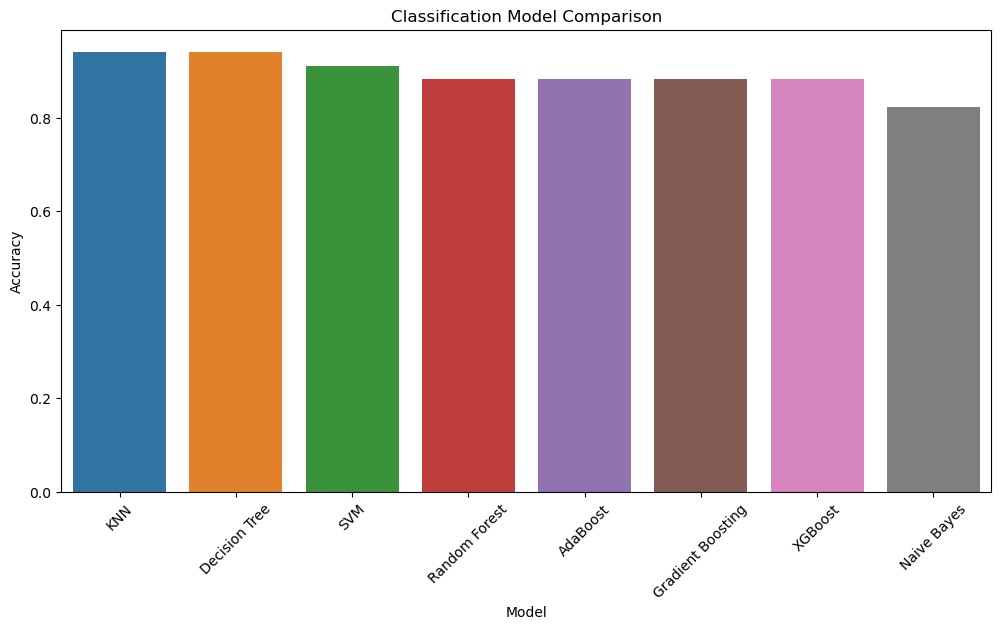

In [30]:
plt.figure(figsize=(12,6))
sns.barplot(x='Model',y='Accuracy',data=results_df)
plt.xticks(rotation=45)
plt.title("Classification Model Comparison")
plt.show()

In [31]:
#Feature Importance
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
importance = pd.DataFrame({'Feature': feature_names,'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
importance

,Feature,Importance
6,life_expec,0.315214
0,child_mort,0.228473
4,income,0.138320
8,gdpp,0.133023
7,total_fer,0.124357
1,exports,0.022294
5,inflation,0.015410
3,imports,0.011783
2,health,0.011126


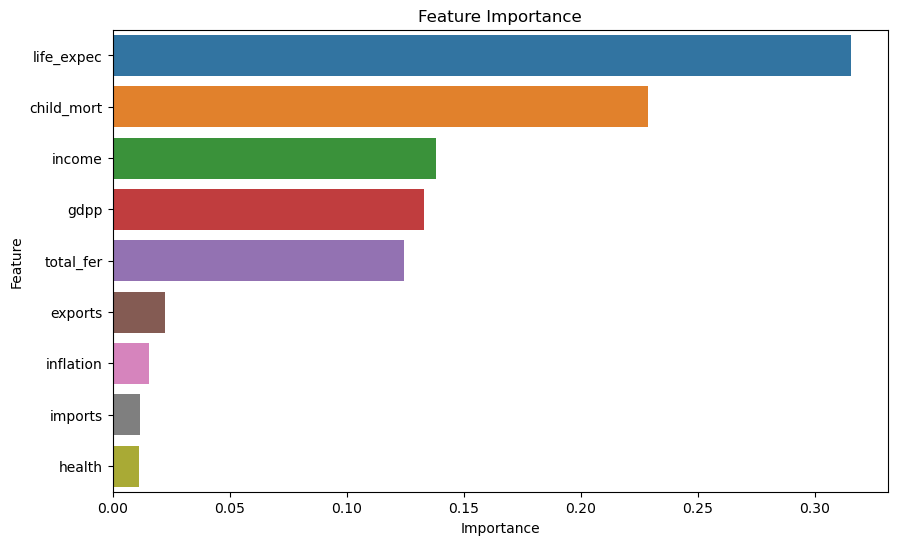

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=importance)
plt.title("Feature Importance")
plt.show()